## SkillCraft DataScience Internship

#### Task 2:Titanic Dataset- Data Cleaning and Exploratory Data Analysis(EDA)

##### Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


##### Load Dataset

In [3]:
df=pd.read_csv("/home/user/Downloads/train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### Dataset Overview

In [ ]:
print("shape:" ,df.shape)
df.info()


shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
print(df.isnull().sum())
print("duplicate rows:",df.duplicated().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
duplicate rows: 0


##### Data Cleaning

In [9]:
# Fill Missing Age Values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Missing Embarked Values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin Column
df.drop("Cabin", axis=1, inplace=True)

# Remove Duplicate Records
df.drop_duplicates(inplace=True)

print("Missing Values After Cleaning")
print(df.isnull().sum())


Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Exploratory Data Analysis

#### Survival Distribution

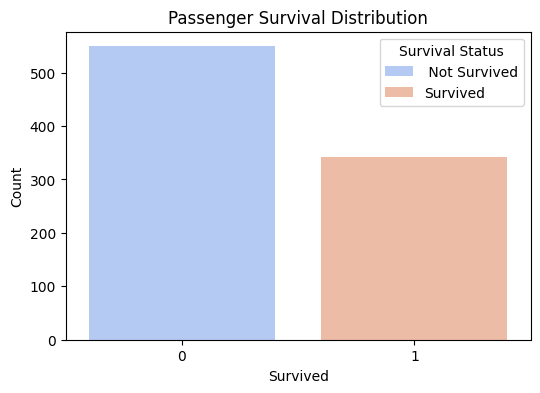

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived",data=df,palette="coolwarm",hue='Survived')

plt.title("Passenger Survival Distribution")

plt.xlabel("Survived")

plt.ylabel("Count")
plt.legend(title="Survival Status",
    labels=[" Not Survived", "Survived"])

plt.show()


##### The majority of passengers did not survive the Titanic disaster, indicating a higher fatality rate than survival rate.

##### Survival by Gender

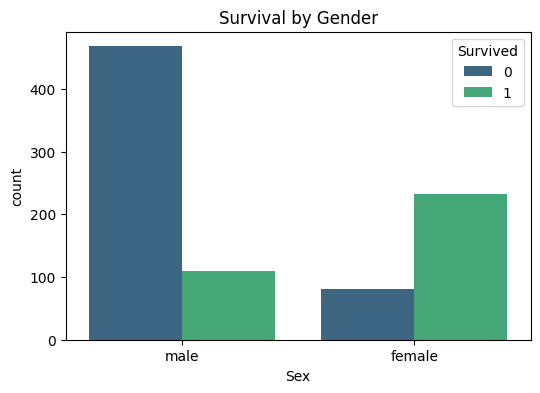

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex",
              hue="Survived",
              data=df,
              palette="viridis")

plt.title("Survival by Gender")

plt.show()


##### Description

##### Female passengers had a much higher survival rate than male passengers, indicating that women were prioritized during evacuation.


##### Age Distribution

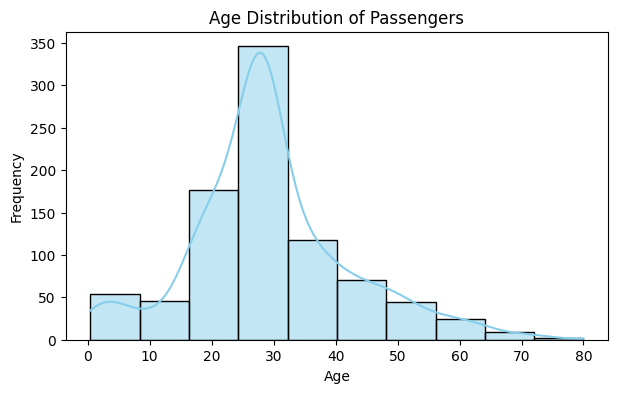

In [37]:
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


##### Most passengers were between 20 and 40 years old. The age distribution is slightly right-skewed, with fewer elderly passengers and a small number of children on board.

#### Survival by Age

In [39]:
# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)


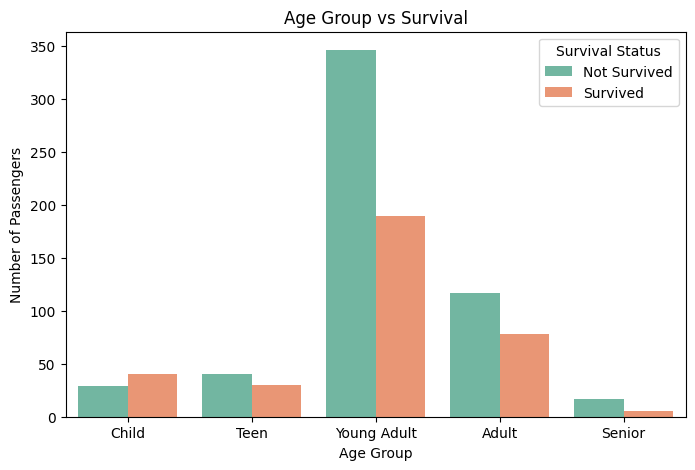

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="AgeGroup",
    hue="Survived",
    data=df,
    palette="Set2"
)

plt.title("Age Group vs Survival")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survival Status",
    labels=["Not Survived", "Survived"]
)

plt.show()


##### Age Group vs Survival: This count plot compares the number of survivors and non-survivors across different age groups. Young adults formed the largest passenger group, while children showed a relatively higher proportion of survivors. Adult and senior passengers experienced more fatalities than survivals, suggesting that age had some influence on survival, although it was less significant than factors such as gender and passenger class.

#### Conclusion

##### The exploratory data analysis of the Titanic dataset revealed that gender, passenger class, and fare had the greatest impact on passenger survival. Female and first-class passengers were more likely to survive, while third-class passengers experienced the highest mortality. Age showed some influence, with children having relatively better survival rates. Overall, the analysis demonstrates how EDA helps uncover meaningful patterns and prepares the dataset for future predictive modeling.